# Data Understanding

## Objective

On this section, an initial exploration of the data set is carried out to understand its structure, types of variables, data quality and potential problems that will need to be addressed during the clean-up phase.

The analyses carried out in this phase do not modify the dataset; they only allow to know its characteristics and prepare the next stages of the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional configuration for visual improvement

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [2]:
# Load the dataset

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Display the first rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Structure

The first step is to inspect the overall structure of the dataset. This includes the number of observations, the available features, data types, memory usage, and potential missing values.

Understanding the dataset at this stage helps identify potential data quality issues before performing any preprocessing.

In [4]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Dataset Dimensions

The dataset dimensions indicate the number of observations (rows) and features (columns).

This provides a quick overview of the dataset size before proceeding with further analysis.

In [5]:
# Display dataset dimensions

df.shape

(7043, 21)

## Feature Names

Displaying the feature names provides an overview of the available information in the dataset and helps identify the variables that may require further analysis.

In [6]:
# Display column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Descriptive Statistics

Descriptive statistics summarize the numerical features of the dataset, providing information such as the mean, standard deviation, minimum, maximum, and quartiles.

These statistics help identify unusual values and understand the distribution of the data.

In [7]:
# Generate descriptive statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observations

- The dataset contains 7,043 customer records.
- Most numerical features appear to have valid ranges.
- No obvious inconsistencies were identified at this stage.
- Further validation is required to inspect missing values and categorical variables.

## Data Types

Inspecting the data types helps determine whether each feature has the appropriate format for analysis and modeling.

It also allows us to identify columns that may require type conversion during the data cleaning phase.

In [8]:
# Display data types

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

## Missing Values

Missing values can negatively affect both data analysis and machine learning models.

This step identifies the number of missing values in each feature before deciding how they should be handled.

In [ ]:
# Count missing values (optional, the basic form is df.isnull().sum())

(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

## Duplicate Records

Duplicate records may introduce bias into the analysis and affect the performance of machine learning models.

This step checks whether duplicated observations exist in the dataset.

In [ ]:
# Count duplicate rows

df.duplicated().sum()

np.int64(0)

### Observations

- Most features appear to have appropriate data types.
- The dataset will be inspected for missing values before data cleaning.
- Duplicate records will be evaluated to ensure data quality.

## Target Variable Distribution

The target variable is the feature that the machine learning model will learn to predict.

Analyzing its distribution helps determine whether the dataset is balanced and provides an initial understanding of the prediction problem.

In [13]:
# Display target variable distribution

display(df["Churn"].value_counts())

# Display target variable distribution as percentages

display(df["Churn"].value_counts(normalize=True).mul(100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

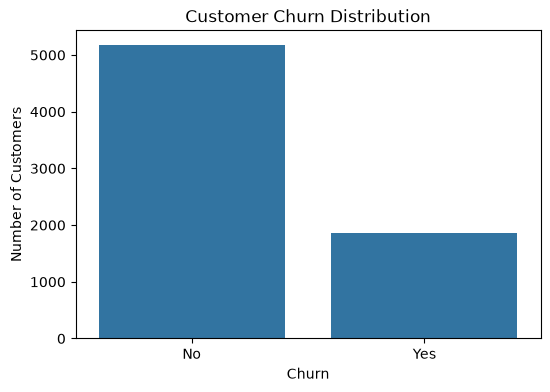

In [14]:
# Plot the target variable distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Feature Classification

Separating numerical and categorical features helps define the appropriate preprocessing techniques for each type of variable before training the machine learning models.

In [16]:
# Identify numerical features

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

display(numerical_features)

# Identify categorical features

categorical_features = df.select_dtypes(include=["object", "string"]).columns

display(categorical_features)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

### Observations

- The target variable is moderately imbalanced.
- Most customers did not churn.
- The dataset contains both numerical and categorical features.
- Categorical variables will require encoding before model training.
- The `TotalCharges` feature will require further inspection due to its current data type.

## Dataset Summary

This section summarizes the main characteristics of the dataset identified during the data understanding phase.

In [17]:
# Dataset summary

summary = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Numerical Features",
        "Categorical Features",
        "Duplicate Records"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        len(numerical_features),
        len(categorical_features),
        df.duplicated().sum()
    ]
})

display(summary)

,Metric,Value
0,Number of Rows,7043
1,Number of Columns,21
2,Numerical Features,3
3,Categorical Features,18
4,Duplicate Records,0


## Final Observations

- The dataset contains 7,043 customer records and 21 features.
- No duplicate records were identified.
- The `TotalCharges` feature requires data type conversion before modeling.
- The dataset contains both numerical and categorical variables.
- The target variable is moderately imbalanced, which should be considered during model evaluation.